In [1]:
import numpy as np
import numpy
import pandas as pd
import math 
from scipy.stats import norm
import scipy.optimize as opt
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from operator import length_hint
import scipy
import seaborn as sns
import sympy
from sympy import *     
from pandas import Series,DataFrame
from datetime import datetime
from scipy import stats
import heapq
from scipy import interpolate
from scipy.optimize import fsolve
from sklearn.metrics import roc_curve, auc

In [3]:
Name1 = "6211_LEH"       #Delisted company SIC code+ticker
Name2 = "6211_GS_LEH"         #Listed company SIC code+ticker
TIME = 30            
Time = 20111010     

In [5]:
Company = pd.read_csv('~/Documents/Data/delisted_new_t/6211_LEH_option.csv')
Data1 = Company
Mark=Data1.iloc[-1,0]
list=[]
count=1
for i in range(Data1.shape[0]):
    if Mark!=Data1.iloc[-(i+1),0]:
        count=count+1
        Mark=Data1.iloc[-(i+1),0]
    if count==TIME+1:
        break
    list.append(-(i+1))
Data2 =Data1.loc[Data1.index[list],:]
Data2=Data2.iloc[::-1]

In [7]:
K = Data2.iloc[:, 2]
S = Data2.iloc[:, 4]
# Filter in-the-money data
def remove_in_the_money_options(Data2):
    Data2.iloc[:, 2] = pd.to_numeric(Data2.iloc[:, 2], errors='coerce')  # 行權價 K
    Data2.iloc[:, 4] = pd.to_numeric(Data2.iloc[:, 4], errors='coerce')  # 標的資產現價 S


    K = Data2.iloc[:, 2]
    S = Data2.iloc[:, 4]
    
    # C for call, P for put
    option_type = Data2.iloc[:, 8]
    
    # con1: Call and S > K (in-the-money)
    condition_call = (option_type == 'C') & (S > K)
    
    # con2: Put and S < K (in-the-money)
    condition_put = (option_type == 'P') & (S < K)
    

    Data3 = Data2[~(condition_call | condition_put)]
    
    return Data3
Data3 = remove_in_the_money_options(Data2)

In [9]:
#Convert to put prices
for i in range(Data3.shape[0]):
    if Data3.iloc[i, 8] == 'C':  
        # 提取S、K、r、T值
        S = Data3.iloc[i, 4]  # S
        K = Data3.iloc[i, 2]  # K
        r = Data3.iloc[i, 5]  # r
        T = Data3.iloc[i, 3]  # T
        
        P_converted = K * np.exp(-r * T) - S
        
        Data3.iloc[i, 9] = P_converted

In [11]:
#Date record
T = Data2.iloc[:,3]
R = Data2.iloc[:,5]
F = Data2.iloc[:,6]
S = Data2.iloc[:,4]
date=Data1.iloc[0,0]
Variable = pd.concat([R,T,S,F], axis=1)
Variable.columns = ['Rate','Time','Stock Price','Future Price']
Variable=Variable.iloc[len(Variable)-TIME:len(Variable),:]
S1 = pd.read_csv('~/Documents/Data/Archive_de_stock/6211_LEH_stock.csv')
Time = datetime(2001, 9, 3)
S1['date'] = pd.to_datetime(S1['date'], format='%Y/%m/%d', errors='coerce')
S1 = S1[S1["date"] >= Time].reset_index(drop=True)
Datelist = S1["date"].iloc[-TIME:].tolist()
S1 = Series(S1["close"].tolist())

In [13]:
#Find longest K
Num = []
date = Data3.iloc[0, 0]
A = 0
for i in range(Data3.shape[0]):
    if Data3.iloc[i, 0] == date:
        A = A + 1
    else:
        date = Data3.iloc[i, 0]
        Num.append(A)
        A = 1
Num.append(A)
Strike = max(Num)

print("Strike:", Strike)
print("Variable.shape[0]:", Variable.shape[0])


K = pd.DataFrame(columns=range(Variable.shape[0]), index=range(Strike))  # 創建一個 DataFrame，行數是 Strike，列數是 Variable 的行數
date = Data3.iloc[0, 0] 
row = 0 
Column = 0 

for i in range(Data3.shape[0]):  
    if Data3.iloc[i, 0] == date:  
        if Column < Strike and row < Variable.shape[0]:  
            K.iloc[Column, row] = Data3.iloc[i, 2] 
        Column = Column + 1  
    else:  
        date = Data3.iloc[i, 0] 
        row = row + 1  
        Column = 0  
        if Column < Strike and row < Variable.shape[0]: 
            K.iloc[Column, row] = Data3.iloc[i, 2]  
        Column = Column + 1  

# Price
P = pd.DataFrame(columns=range(Variable.shape[0]), index=range(Strike))
date = Data3.iloc[0, 0]
row = 0
Column = 0
for i in range(Data3.shape[0]):
    if Data3.iloc[i, 0] == date:
        if Column < Strike and row < Variable.shape[0]:
            P.iloc[Column, row] = Data3.iloc[i, 9]
        Column = Column + 1
    else:
        date = Data3.iloc[i, 0]
        row = row + 1
        Column = 0
        if Column < Strike and row < Variable.shape[0]:
            P.iloc[Column, row] = Data3.iloc[i, 9]
        Column = Column + 1

Strike: 26
Variable.shape[0]: 30


30  Days before default
MAPE= 0.7677
Default probability=:  0.0997 %
RND= : 
[0.002 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.998 0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
--------------------------------------------------------------------
18.7046204620462
29  Days before default
MAPE= 0.5076
Default probability=:  3.3 %
RND= : 
[0.066  0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.7437 0.1903 0.     0.     0.     0.     0.     0.
 

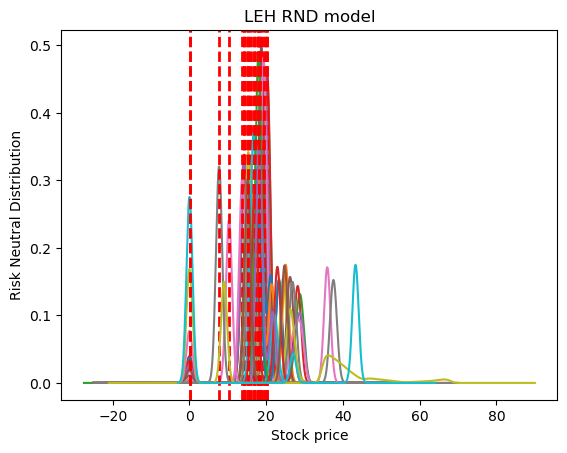

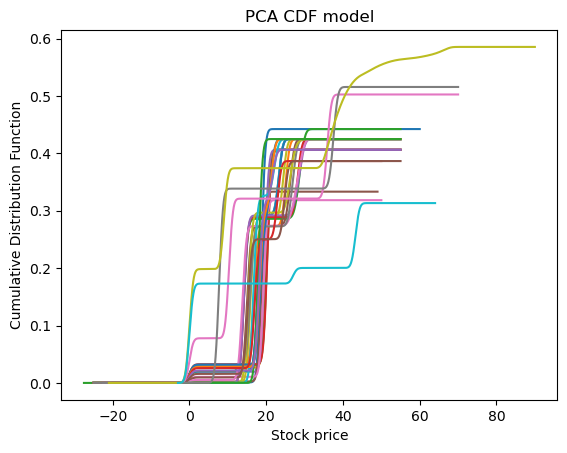

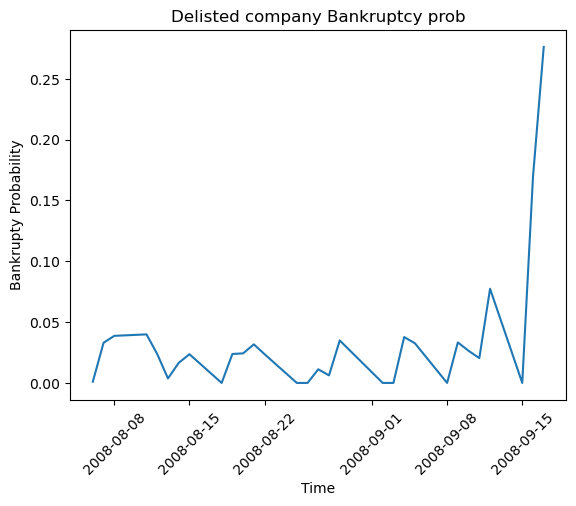

In [19]:
Problist_delisted = []
MSErecord_delisted=0
MAPErecord_delisted = []
for i in range(len(Variable)):

    Option_data = pd.DataFrame(zip(K.iloc[:,i],P.iloc[:,i]), columns = ['Strike price','Price']).dropna(axis=0)
    Option_data = Option_data.sort_values(by=['Strike price'], ascending=True)
    Opt_len = Option_data.shape[0]
    dz=0.4
    h=2*dz
    Z=numpy.arange(Option_data.iloc[0,0],Option_data.iloc[Opt_len-1,0]+dz,dz).tolist()
    Z.insert(0,0)
    dis=length_hint(Z) 
    PCA_1 = pd.DataFrame(columns=Option_data.iloc[:,0],index=Z)
    for k in range(Opt_len):
        for j in range(dis):
            PCA_1.iloc[j,k]=(Option_data.iloc[k,0]-Z[j])/h
    
    #Apply PCA
    PCA_2= pd.DataFrame(columns=Option_data.iloc[:,0],index=Z)
    for k in range(Opt_len):
        for j in range(dis):
            PCA_2.iloc[j,k]=(math.exp(-0.5*(PCA_1.iloc[j,k])**2)/math.sqrt(2*math.pi)+PCA_1.iloc[j,k]*norm.cdf(PCA_1.iloc[j,k]))/h
  
    #Optimization
    def PCA_fnc(a):
        PCA=0
        for k in range(Opt_len):
            Sum=0
            for j in range(dis):
                Sum=Sum+a[j]*PCA_2.iloc[j,k]
            PCA=PCA+abs((Option_data.iloc[k,1]-Sum)/Option_data.iloc[k,1])
        return PCA

    def con(a):
        A=np.sum(a)
        return A-1
    def con_F(a):
        B=0
        for j in range(dis):
            B=B+a[j]*Z[j]
        return B-F.iloc[i]
    cons = [{'type':'eq', 'fun': con},
            {'type':'eq', 'fun': con_F}]
    a0=[1/dis]*dis
    PCA_fnc(a=a0)
    bounds = [(0,1)]*dis
    res = opt.minimize(PCA_fnc,a0,bounds=bounds,constraints=cons)
    
    #print results
    print(len(Variable)-i ," Days before default")
    print("MAPE=",np.round(res['fun']/Opt_len,decimals=4))
    MSErecord_delisted = MSErecord_delisted+np.round(res['fun']/Opt_len,decimals=4)
    MAPErecord_delisted.append(np.round(res['fun'] / Opt_len, decimals=4))
    def PCA(x):
        SUM_RND=0
        for j in range(dis):
            SUM_RND=SUM_RND+res['x'][j]*(sympy.exp(-0.5*((x-Z[j])/h)**2)/(2*sympy.pi)**0.5)/h
        return(SUM_RND)  
    x = symbols('x')
    Prob = integrate(PCA(x), (x,-float("inf"),0)).simplify()
    Problist_delisted.append(np.round(float(Prob),decimals=4))
    Prob = np.round(float(Prob)*100,decimals=4)
    print("Default probability=: ", Prob,"%")
    print("RND= : ")
    print(np.round(res['x'],decimals=4))
    print("--------------------------------------------------------------------")
    #Plot
    
    
    x=np.linspace(min(Option_data.iloc[:,0])-30,max(Option_data.iloc[:,0])+20,10000)
    y=[]
    for S in x:
        SUM_RND=0
        for j in range(dis):
            SUM_RND=SUM_RND+res['x'][j]*(math.exp(-0.5*((S-Z[j])/h)**2)/math.sqrt(2*math.pi))/h
        y.append(SUM_RND)
    high=np.argmax(y)+1
    print(x[high])
    #plt.subplot(2, 3, i+1) 
    plt.figure(1)
    plt.plot(x,y)
    plt.title(Name1[5:]+" RND model")
    plt.xlabel("Stock price")
    plt.ylabel("Risk Neutral Distribution")
    plt.axvline(x=x[high],linewidth=2,linestyle="--",color="r")
    
    plt.figure(2)
    z=[]
    cdf = 0
    for S in x:
        SUM_RND=0
        for j in range(dis):
            SUM_RND=SUM_RND+res['x'][j]*(math.exp(-0.5*((S-Z[j])/h)**2)/math.sqrt(2*math.pi))/h
        cdf = cdf + SUM_RND/10000*(max(Option_data.iloc[:,0])-min(Option_data.iloc[:,0])+4)
        z.append(cdf)
        
    plt.plot(x,z)
    plt.title("PCA CDF model")
    plt.xlabel("Stock price")
    plt.ylabel("Cumulative Distribution Function")
    
plt.figure(3)
plt.plot(Datelist,Problist_delisted)
plt.xticks(rotation=45)
plt.title("Delisted company Bankruptcy prob")
plt.xlabel("Time")
plt.ylabel("Bankrupty Probability")
print("Average Default Probability:",np.round(np.mean(Problist_delisted)*100,decimals=2),"%")
print("Default Probability Standard Deviation:",np.round(np.std(Problist_delisted),decimals=2))
print("Average MAPE=:",np.round(MSErecord_delisted/TIME,decimals=4)*100,"%")
print("Average Daily Data",np.round(Data3.shape[0]/TIME,decimals=2))